# H2O AutoML Level 3

In [1]:
!pip install -U pip
!pip install -U h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 56.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 33.1 MB/s  0:00:07


In [2]:
!pip install -q h2o shap lime


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
import json
import math
import warnings
from pathlib import Path
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

import h2o
from h2o.automl import H2OAutoML

import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 9})


# 0) User Configs

In [4]:
TRAIN_PATH = "/content/train_raw.csv"
VAL_PATH   = "/content/val_raw.csv"
TEST_PATH  = "/content/test_raw.csv"

OUT_DIR = "/content/h2o_level3_outputs"
MODEL_DIR = os.path.join(OUT_DIR, "h2o_model")
EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
PLOT_DIR = os.path.join(OUT_DIR, "thesis_plots")


os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EXPLAIN_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "Default"
SEED = 42

# H2O AutoML runtime control
MAX_RUNTIME_SECS = 600

# Rating-grade logic
N_RISK_GRADES = 10
MIN_GRADE_SHARE = 0.03       # minimum 3% per grade, used as diagnostic

# Conservative uplift for proxy-LRADR approximation
CONSERVATISM_UPLIFT = 0.30

# Explainability settings
EXPLAIN_N_ROWS = 1000
LOCAL_EXPLAIN_ROW_INDEXES = [0, 1, 2]

# Optional illustrative PD floor
APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

# moc_a
MOC_A_UPLIFT = 0.05

# Bootstrap sizes, lower numbers as each time a new model is created --> high runtime costs
N_BOOT_TEST = 5
N_BOOT_TRAIN = 3
BOOTSTRAP_TIME_LIMIT = 60
BOOTSTRAP_MAX_MODELS = 3

h2o.init(max_mem_size="8G")


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.19" 2026-04-21; OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu); OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmph79cs1uw
  JVM stdout: /tmp/tmph79cs1uw/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmph79cs1uw/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,17 days
H2O_cluster_name:,H2O_from_python_unknownUser_8zjxgz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


# 1) Helper Functions

In [5]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))


def ks_statistic(y_true, pd_pred):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    }).sort_values("pd", ascending=False)

    total_bad = max((tmp["y"] == 1).sum(), 1)
    total_good = max((tmp["y"] == 0).sum(), 1)

    cum_bad = (tmp["y"] == 1).cumsum() / total_bad
    cum_good = (tmp["y"] == 0).cumsum() / total_good

    return float(np.max(np.abs(cum_bad - cum_good)))


def calibration_table(y_true, pd_pred, n_buckets=10):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    })

    tmp["bucket"] = pd.qcut(tmp["pd"], q=n_buckets, duplicates="drop")

    out = tmp.groupby("bucket", observed=False).agg(
        obs=("y", "count"),
        defaults=("y", "sum"),
        avg_pd=("pd", "mean"),
        pd_min=("pd", "min"),
        pd_max=("pd", "max"),
    ).reset_index()

    out["observed_dr"] = out["defaults"] / out["obs"]
    out["calibration_gap"] = out["avg_pd"] - out["observed_dr"]

    return out


def hosmer_lemeshow_like(y_true, pd_pred, n_buckets=10):
    tab = calibration_table(y_true, pd_pred, n_buckets)
    eps = 1e-8

    expected_bad = np.clip(tab["avg_pd"] * tab["obs"], eps, None)
    expected_good = np.clip((1 - tab["avg_pd"]) * tab["obs"], eps, None)

    observed_bad = tab["defaults"]
    observed_good = tab["obs"] - tab["defaults"]

    hl = ((observed_bad - expected_bad) ** 2 / expected_bad).sum()
    hl += ((observed_good - expected_good) ** 2 / expected_good).sum()

    return float(hl)


def evaluate_pd(y_true, pd_pred, prefix):
    auc_value = roc_auc_score(y_true, pd_pred)

    return {
        f"{prefix}_auc": float(auc_value),
        f"{prefix}_gini": float(2 * auc_value - 1),
        f"{prefix}_ks": ks_statistic(y_true, pd_pred),
        f"{prefix}_brier": float(brier_score_loss(y_true, pd_pred)),
        f"{prefix}_logloss": float(log_loss(y_true, pd_pred)),
        f"{prefix}_hl_like": hosmer_lemeshow_like(y_true, pd_pred),
        f"{prefix}_mean_pd": float(np.mean(pd_pred)),
        f"{prefix}_obs_dr": float(np.mean(y_true)),
    }

def population_stability_index(reference, current, buckets=10):
    reference = pd.Series(reference).astype(float)
    current = pd.Series(current).astype(float)

    cuts = np.unique(np.quantile(reference, np.linspace(0, 1, buckets + 1)))

    if len(cuts) < 3:
        return 0.0

    cuts[0] = -np.inf
    cuts[-1] = np.inf

    reference_bins = pd.cut(reference, bins=cuts, include_lowest=True)
    current_bins = pd.cut(current, bins=cuts, include_lowest=True)

    reference_dist = reference_bins.value_counts(normalize=True, sort=False)
    current_dist = current_bins.value_counts(normalize=True, sort=False)

    psi = 0.0
    for bucket in reference_dist.index:
        pe = max(float(reference_dist.get(bucket, 0)), 1e-8)
        pa = max(float(current_dist.get(bucket, 0)), 1e-8)
        psi += (pa - pe) * math.log(pa / pe)

    return float(psi)

def calibrate_to_target_lradr(pd_values, target_mean, tol=1e-12):
    """
    Apply one global logit shift so that the average PD equals the proxy LRADR.
    """
    if not (0 < target_mean < 1):
        raise ValueError("target_mean must be between 0 and 1")

    base_logit = logit(pd_values)

    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            break

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    return inv_logit(base_logit + alpha), float(alpha)


def apply_final_pd_adjustments(pd_be, moc_a=None, moc_c=None, pd_floor=PD_FLOOR):
    pd_final = np.asarray(pd_be, dtype=float)

    if moc_a is not None:
        pd_final = pd_final + np.asarray(moc_a, dtype=float)

    if moc_c is not None:
        pd_final = pd_final + np.asarray(moc_c, dtype=float)

    if APPLY_PD_FLOOR:
        pd_final = np.maximum(pd_final, pd_floor)

    return np.clip(pd_final, 0, 1)


def initial_pd_quantile_grades(df, pd_col, n_grades=N_RISK_GRADES):
    out = df.copy()
    out["risk_grade"] = pd.qcut(
        out[pd_col],
        q=n_grades,
        labels=False,
        duplicates="drop"
    ) + 1

    return out



def risk_grade_table(df, target_col, pd_cols, grade_col="risk_grade"):
    agg_dict = {
        "obs": (target_col, "count"),
        "defaults": (target_col, "sum"),
    }

    for col in pd_cols:
        agg_dict[f"avg_{col}"] = (col, "mean")
        agg_dict[f"min_{col}"] = (col, "min")
        agg_dict[f"max_{col}"] = (col, "max")

    tab = df.groupby(grade_col, observed=False).agg(**agg_dict).reset_index()
    tab["observed_dr"] = tab["defaults"] / tab["obs"]

    if f"avg_{pd_cols[-1]}" in tab.columns:
        tab["gap_final"] = tab[f"avg_{pd_cols[-1]}"] - tab["observed_dr"]

    tab["obs_share"] = tab["obs"] / tab["obs"].sum()
    tab["observed_dr_monotonic_increasing"] = tab["observed_dr"].is_monotonic_increasing

    return tab


def enforce_monotonic_grade_table(tab, grade_col="risk_grade"):
    """
    Conservative post-processing:
    If neighboring grades violate monotonic observed default rates,
    merge them until observed DR is monotonic increasing.

    This produces a rating table. It does not change the model PDs.
    """
    work = tab.copy()
    work["grade_group"] = work[grade_col].astype(str)

    while True:
        dr = work["observed_dr"].values
        violations = np.where(np.diff(dr) < 0)[0]

        if len(violations) == 0:
            break

        i = int(violations[0])

        # merge row i and i+1
        merged = work.iloc[i].copy()
        nxt = work.iloc[i + 1].copy()

        merged["grade_group"] = f"{merged['grade_group']}-{nxt['grade_group']}"
        merged["obs"] = merged["obs"] + nxt["obs"]
        merged["defaults"] = merged["defaults"] + nxt["defaults"]

        for col in work.columns:
            if col.startswith("avg_"):
                base = col.replace("avg_", "")
                # weighted average of averages
                merged[col] = (
                    work.iloc[i][col] * work.iloc[i]["obs"] +
                    work.iloc[i + 1][col] * work.iloc[i + 1]["obs"]
                ) / merged["obs"]

            if col.startswith("min_"):
                merged[col] = min(work.iloc[i][col], work.iloc[i + 1][col])

            if col.startswith("max_"):
                merged[col] = max(work.iloc[i][col], work.iloc[i + 1][col])

        merged["observed_dr"] = merged["defaults"] / merged["obs"]
        merged["obs_share"] = np.nan
        if "gap_final" in work.columns:
            final_avg_cols = [c for c in work.columns if c.startswith("avg_PD_final")]
            if final_avg_cols:
                merged["gap_final"] = merged[final_avg_cols[0]] - merged["observed_dr"]

        work = pd.concat(
            [work.iloc[:i], pd.DataFrame([merged]), work.iloc[i + 2:]],
            ignore_index=True
        )

    work["final_risk_grade"] = np.arange(1, len(work) + 1)
    work["obs_share"] = work["obs"] / work["obs"].sum()
    work["observed_dr_monotonic_increasing"] = work["observed_dr"].is_monotonic_increasing

    return work

def assign_final_grades_from_mapping(df, mapping_table, initial_grade_col="risk_grade"):
    """
    Assign merged final grades back to observations.
    """
    out = df.copy()

    lookup = []
    for _, row in mapping_table.iterrows():
        group = str(row["grade_group"])
        parts = [int(x) for x in group.split("-")]
        low = min(parts)
        high = max(parts)

        for g in range(low, high + 1):
            lookup.append({
                initial_grade_col: g,
                "final_risk_grade": int(row["final_risk_grade"])
            })

    lookup = pd.DataFrame(lookup)
    out = out.merge(lookup, on=initial_grade_col, how="left")

    return out


def rank_ordering_table(scorecard_df):
    out = scorecard_df[[
        "final_risk_grade",
        "obs",
        "defaults",
        "observed_dr",
        "avg_PD_final",
        "min_PD_final",
        "max_PD_final",
        "gap_final",
    ]].copy()

    return out

def make_h2o_frame(df, target=TARGET):
    frame = h2o.H2OFrame(df)
    frame[target] = frame[target].asfactor()
    return frame


def train_h2o_automl_bootstrap(
    train_h2o,
    val_h2o,
    features,
    target,
    max_runtime_secs,
    max_models,
    seed,
):
    aml_boot = H2OAutoML(
        max_runtime_secs=max_runtime_secs,
        max_models=BOOTSTRAP_MAX_MODELS,
        seed=seed,
        sort_metric="AUCPR",
        stopping_metric="AUCPR",
        balance_classes=False,
        verbosity="warn",
    )

    aml_boot.train(
        x=features,
        y=target,
        training_frame=train_h2o,
        validation_frame=val_h2o,
        leaderboard_frame=val_h2o,
        weights_column="row_weight"
    )

    return aml_boot


def bootstrap_moc_c_h2o(
    train_data,
    eval_data,
    calibration_alpha,
    features,
    target,
    n_boot=5,
    alpha_q=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    all_pd_predictions = []

    train_data = train_data.reset_index(drop=True)
    eval_data = eval_data.reset_index(drop=True)

    eval_h2o = make_h2o_frame(eval_data, target)

    # make sure weight roe is never in the features
    features_clean = [f for f in features if f != "row_weight"]

    for b in range(n_boot):
        sample_idx = rng.randint(0, len(train_data), len(train_data))
        train_boot = train_data.iloc[sample_idx].reset_index(drop=True)

        # calculating row_weight after Resampling for the dev/val-Splits
        train_boot["row_weight"] = calculate_inverse_weights(train_boot, target)

        train_boot_dev, train_boot_val = train_test_split(
            train_boot,
            test_size=0.20,
            random_state=random_state + b,
            stratify=train_boot[target],
        )

        # convert the DataFrames in H2O-frames
        train_boot_h2o = h2o.H2OFrame(train_boot_dev)
        val_boot_h2o   = h2o.H2OFrame(train_boot_val)

        # Target as factor/category
        train_boot_h2o[target] = train_boot_h2o[target].asfactor()
        val_boot_h2o[target]   = val_boot_h2o[target].asfactor()

        # call the H2O config
        aml_boot = train_h2o_automl_bootstrap(
            train_h2o=train_boot_h2o,
            val_h2o=val_boot_h2o,
            features=features_clean,
            target=target,
            max_runtime_secs=BOOTSTRAP_TIME_LIMIT,
            max_models=BOOTSTRAP_MAX_MODELS,
            seed=random_state + b,
        )

        # no break up if train_h2o_automl_bootstrap ives back None/ no model was finished
        if aml_boot is None or getattr(aml_boot, "leader", None) is None:
            from h2o.estimators import H2OGeneralizedLinearEstimator
            print(f"  [Warning] Bootstrap run {b} timed out before a model was built. Training fast fallback GLM...")

            # Fallback: GLM needs only few seconds
            leader_model = H2OGeneralizedLinearEstimator(family="binomial", seed=random_state + b)
            leader_model.train(
                x=features_clean,
                y=target,
                training_frame=train_boot_h2o,
                weights_column="row_weight"
            )
        else:
            leader_model = aml_boot.leader

        # predictions PD with the "new" models
        pd_raw = get_positive_class_proba_h2o(leader_model, eval_h2o)
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

        # deleting all inbetween-models
        try:
            if aml_boot is not None and getattr(aml_boot, "leaderboard", None) is not None:
                model_ids = aml_boot.leaderboard.as_data_frame()["model_id"].tolist()
                for model_id in model_ids:
                    try:
                        h2o.remove(model_id)
                    except Exception:
                        pass

            # if fallback mdeols was used, explicitly delet this one
            if aml_boot is None or getattr(aml_boot, "leader", None) is None:
                h2o.remove(leader_model.model_id)

            h2o.remove(train_boot_h2o)
            h2o.remove(val_boot_h2o)
        except Exception:
            pass

    pred_matrix = np.vstack(all_pd_predictions)

    pd_mean = pred_matrix.mean(axis=0)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)

    try:
        h2o.remove(eval_h2o)
    except Exception:
        pass

    return pd_mean, moc_c, pred_matrix


def get_positive_class_proba_h2o(model, data_h2o):
    pred = model.predict(data_h2o).as_data_frame()

    if "p1" in pred.columns:
        return pred["p1"].astype(float).values

    # Robust fallback if H2O changes column names or class labels are strings
    proba_cols = [c for c in pred.columns if c.startswith("p")]
    if len(proba_cols) >= 2:
        return pred[proba_cols[-1]].astype(float).values

    raise ValueError(f"Could not identify positive-class probability column. Columns: {list(pred.columns)}")

# Calculation of Row Weights (Inverse Class Frequency) so it is comparable to AutoGluon ( in H20 there is no in-bulid hyperparameter)
def calculate_inverse_weights(df, target_col):
    total_samples = len(df)
    n_classes = df[target_col].nunique()

    # Count the frequency of each class
    class_counts = df[target_col].value_counts()

    # formular for balanced weights: total_samples / (n_classes * class_count)
    weights_map = {
        cls: total_samples / (n_classes * count)
        for cls, count in class_counts.items()
    }

    # Map weights to the rows
    return df[target_col].map(weights_map)

# 2) Load fixed Splits

In [6]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

if TARGET not in train.columns:
    raise ValueError(f"Target column '{TARGET}' not found in train data.")

if TARGET not in val.columns:
    raise ValueError(f"Target column '{TARGET}' not found in validation data.")

if TARGET not in test.columns:
    raise ValueError(f"Target column '{TARGET}' not found in test data.")

# Ensure binary target is represented consistently as 0/1 integers in pandas.
for df_name, df in [("train", train), ("val", val), ("test", test)]:
    df[TARGET] = df[TARGET].astype(int)
    unique_values = sorted(df[TARGET].dropna().unique())
    if not set(unique_values).issubset({0, 1}):
        raise ValueError(f"{df_name}: Target must be binary 0/1. Found: {unique_values}")

### for the row weight ##
train = train.copy()
val = val.copy()
test = test.copy()

train["row_weight"] = calculate_inverse_weights(train, TARGET)
val["row_weight"] = calculate_inverse_weights(val, TARGET)
test["row_weight"] = 1.0    # Prevents the "missing column" warning in the test set


Train shape: (153207, 17)
Val shape: (51070, 17)
Test shape: (51070, 17)


# 3) Start H2O and convert data

In [7]:
# H2O cluster

h2o.init(max_mem_size="10G")
h2o.no_progress()

# Convert pandas DataFrames to H2OFrames
train_h2o = h2o.H2OFrame(train)
val_h2o   = h2o.H2OFrame(val)
test_h2o  = h2o.H2OFrame(test)

# H2O needs the binary target as factor/categorical for classification.
train_h2o[TARGET] = train_h2o[TARGET].asfactor()
val_h2o[TARGET]   = val_h2o[TARGET].asfactor()
test_h2o[TARGET]  = test_h2o[TARGET].asfactor()

#  'row_weight' is not a feature --> risk of Data Leakage (as it learns the weights for prediction)
FEATURES = [c for c in train.columns if c not in [TARGET, "row_weight"]]

print("Number of features:", len(FEATURES))
print("Features:", FEATURES)




Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,17 days
H2O_cluster_name:,H2O_from_python_unknownUser_8zjxgz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Number of features: 16
Features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


# 4) H2O AutoML

In [8]:
aml_kwargs = {
    "max_runtime_secs": MAX_RUNTIME_SECS,
    "seed": SEED,
    "sort_metric": "AUCPR",
    "stopping_metric": "AUCPR",
    "balance_classes": False,      # False as weight_row is used
    "verbosity": "info",
}


aml = H2OAutoML(**aml_kwargs)

aml.train(
    x=FEATURES,
    y=TARGET,
    training_frame=train_h2o,
    validation_frame=val_h2o,
    leaderboard_frame=val_h2o,
    weights_column="row_weight"   # Forces H2O to use mathematical loss weighting
)

leader = aml.leader

print("Best H2O model id:")
print(leader.model_id)

# Save H2O leader model
saved_model_path = h2o.save_model(
    model=leader,
    path=MODEL_DIR,
    force=True,
)

print("Saved H2O leader model to:", saved_model_path)



00:06:46.357: Project: AutoML_1_20260609_00646
00:06:46.361: 5-fold cross-validation will be used.
00:06:46.361: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.
00:06:46.368: Setting stopping tolerance adaptively based on the training frame: 0.0025548222848548437
00:06:46.368: Build control seed: 42
00:06:46.370: training frame: Frame key: AutoML_1_20260609_00646_training_py_1_sid_9e48    cols: 18    rows: 153207  chunks: 5    size: 3641122  checksum: -448748897555378768
00:06:46.373: validation frame: Frame key: py_2_sid_9e48    cols: 18    rows: 51070  chunks: 2    size: 1216558  checksum: 3791734936372173160
00:06:46.373: leaderboard frame: Frame key: py_2_sid_9e48    cols: 18    rows: 51070  chunks: 2    size: 1216558  checksum: 3791734936372173160
00:06:46.373: blending fra

# 5) Evaluation on unseen test set

In [9]:
test_results = leader.model_performance(test_h2o)

print(test_results)

ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.20499375201378278
RMSE: 0.4527623571077688
LogLoss: 0.5947121336531168
AUC: 0.753275755214296
AUCPR: 0.3102650672194613
Gini: 0.506551510428592
Null degrees of freedom: 51069
Residual degrees of freedom: 51038
Null deviance: 70798.05302234995
Residual deviance: 60743.897331329346
AIC: 60807.897331329346

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6201824203546811
       0      1      Error    Rate
-----  -----  -----  -------  -----------------
0      37494  7645   0.1694   (7645.0/45139.0)
1      2870   3061   0.4839   (2870.0/5931.0)
Total  40364  10706  0.2059   (10515.0/51070.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.620182     0.367975  114
max f2                       0.461609     0.492322  193
max f0point5                 0.740498    

# 6) Leaderboard

In [10]:
leaderboard = aml.leaderboard.as_data_frame()

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_validation.csv"),
    index=False,
)


                                             model_id     aucpr       auc  \
0                       GLM_1_AutoML_1_20260609_00646  0.737321  0.745407   
1                       GBM_2_AutoML_1_20260609_00646  0.736619  0.741135   
2                       GBM_3_AutoML_1_20260609_00646  0.735687  0.741389   
3                       GBM_1_AutoML_1_20260609_00646  0.735455  0.741105   
4                       GBM_4_AutoML_1_20260609_00646  0.729025  0.734287   
5                   XGBoost_2_AutoML_1_20260609_00646  0.715832  0.719655   
6                   XGBoost_1_AutoML_1_20260609_00646  0.698389  0.707867   
7                       DRF_1_AutoML_1_20260609_00646  0.618984  0.612483   
8   StackedEnsemble_BestOfFamily_1_AutoML_1_202606...  0.312190  0.749788   
9   StackedEnsemble_AllModels_1_AutoML_1_20260609_...  0.186181  0.611724   
10  StackedEnsemble_BestOfFamily_2_AutoML_1_202606...  0.186181  0.611724   

     logloss  mean_per_class_error      rmse       mse  
0   0.595001      

# 7) Calibration

In [11]:
# ============================================================
# raw PD -> BE calibration -> MoC_A -> MoC_C -> PD floor -> final PD
# ============================================================

train_final = pd.concat([train, val], axis=0).reset_index(drop=True)
test_final = test.copy().reset_index(drop=True)

train_final_h2o = make_h2o_frame(train_final, TARGET)
test_final_h2o = make_h2o_frame(test_final, TARGET)

y_train_final = train_final[TARGET].astype(int).to_numpy()
y_test_final = test_final[TARGET].astype(int).to_numpy()

# Raw H2O PDs
pd_train_raw = get_positive_class_proba_h2o(leader, train_final_h2o)
pd_test_raw = get_positive_class_proba_h2o(leader, test_final_h2o)

# Best-estimate calibration to proxy LRADR
observed_train_dr = float(np.mean(y_train_final))

proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
proxy_lradr = min(max(proxy_lradr, 1e-6), 1 - 1e-6)

pd_train_be, alpha_shift = calibrate_to_target_lradr(
    pd_train_raw,
    proxy_lradr
)

pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift)

# MoC_C via bootstrap
pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_h2o(
    train_data=train_final,
    eval_data=train_final,
    calibration_alpha=alpha_shift,
    features=FEATURES,
    target=TARGET,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED,
)

pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_h2o(
    train_data=train_final,
    eval_data=test_final,
    calibration_alpha=alpha_shift,
    features=FEATURES,
    target=TARGET,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# MoC_A
moc_a_train = pd_train_be * MOC_A_UPLIFT
moc_a_test = pd_test_be * MOC_A_UPLIFT

# Final PDs
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
    pd_floor=PD_FLOOR,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
    pd_floor=PD_FLOOR,
)

print("Observed train DR:", observed_train_dr)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print("Mean MoC_A test:", np.mean(moc_a_test))
print("Mean MoC_C test:", np.mean(moc_c_test))
print("Mean final PD test:", np.mean(pd_test_final))

# for documentation
pd_train_final_pre_floor = np.clip(pd_train_be + moc_a_train + moc_c_train, 0, 1)
pd_test_final_pre_floor = np.clip(pd_test_be + moc_a_test + moc_c_test, 0, 1)

# metrics
raw_train_metrics = evaluate_pd(y_train_final, pd_train_raw, "train_raw")
raw_test_metrics = evaluate_pd(y_test_final, pd_test_raw, "test_raw")
be_train_metrics = evaluate_pd(y_train_final, pd_train_be, "train_be")
be_test_metrics = evaluate_pd(y_test_final, pd_test_be, "test_be")
final_train_metrics = evaluate_pd(y_train_final, pd_train_final, "train_final")
final_test_metrics = evaluate_pd(y_test_final, pd_test_final, "test_final")


# Observation-level result table
pd_results_test = test_final.drop(columns=[TARGET]).copy()
pd_results_test["Default_Observed"] = np.asarray(y_test_final)
pd_results_test["PD_raw"] = pd_test_raw
pd_results_test["PD_BE"] = pd_test_be
pd_results_test["MoC_A"] = moc_a_test
pd_results_test["MoC_C"] = moc_c_test

pd_results_test["PD_BE_plus_MoC"] = (
    pd_results_test["PD_BE"]
    + pd_results_test["MoC_A"]
    + pd_results_test["MoC_C"]
)

pd_results_test["PD_final_pre_floor"] = pd_test_final_pre_floor
pd_results_test["PD_final"] = pd_test_final

# Scorecard-like monotonic rating mapping
pd_results_test = initial_pd_quantile_grades(
    df=pd_results_test,
    pd_col="PD_final",
    n_grades=N_RISK_GRADES
)

initial_grade_table = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="risk_grade"
)

scorecard_df = enforce_monotonic_grade_table(initial_grade_table)

pd_results_test = assign_final_grades_from_mapping(
    df=pd_results_test,
    mapping_table=scorecard_df,
    initial_grade_col="risk_grade"
)

# final rank ordering table after merged monotonic grades
rank_ordering = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="final_risk_grade"
)

# Calibration tables
cal_table_raw = calibration_table(y_test_final, pd_test_raw, n_buckets=10)
cal_table_be = calibration_table(y_test_final, pd_test_be, n_buckets=10)
cal_table_final = calibration_table(y_test_final, pd_test_final, n_buckets=10)

# Stability summary
stability_summary = pd.DataFrame({
    "metric": [
        "PSI_raw_train_vs_test",
        "PSI_BE_train_vs_test",
        "PSI_final_train_vs_test",
        "risk_grades_requested",
        "risk_grades_final",
        "min_grade_share",
        "min_observed_grade_share",
    ],
    "value": [
        population_stability_index(pd_train_raw, pd_test_raw),
        population_stability_index(pd_train_be, pd_test_be),
        population_stability_index(pd_train_final, pd_test_final),
        N_RISK_GRADES,
        int(scorecard_df["final_risk_grade"].nunique()),
        MIN_GRADE_SHARE,
        float(scorecard_df["obs_share"].min()),
    ],
})

Observed train DR: 0.11612663197521013
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6886564142805582
Mean MoC_A test: 0.007605389647353276
Mean MoC_C test: 0.0745331203019609
Mean final PD test: 0.23421193132275245


# 8) H2O built-in explainability / transparency

Generating H2O explainability report on 1000 rows...


# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_00646,0.743711,0.308747,0.324851,0.309242,0.298273,0.0889667,73513,0.054784,StackedEnsemble
GLM_1_AutoML_1_20260609_00646,0.742303,0.607479,0.317721,0.306628,0.458853,0.210546,7971,0.008392,GLM
GBM_1_AutoML_1_20260609_00646,0.739493,0.532136,0.308293,0.326979,0.420026,0.176422,14816,0.03222,GBM
GBM_2_AutoML_1_20260609_00646,0.737034,0.610404,0.30614,0.345399,0.45855,0.210268,3688,0.014386,GBM
GBM_4_AutoML_1_20260609_00646,0.731851,0.584892,0.293441,0.322313,0.445135,0.198145,3822,0.014927,GBM
GBM_3_AutoML_1_20260609_00646,0.731354,0.605766,0.330202,0.330357,0.456335,0.208242,3790,0.013754,GBM
XGBoost_2_AutoML_1_20260609_00646,0.703618,0.573887,0.265425,0.352357,0.441443,0.194872,4978,0.009561,XGBoost
XGBoost_1_AutoML_1_20260609_00646,0.674323,0.496987,0.263586,0.368927,0.40428,0.163442,26726,0.024388,XGBoost
StackedEnsemble_AllModels_1_AutoML_1_20260609_00646,0.598013,0.345833,0.190271,0.414414,0.313569,0.0983258,23225,0.013626,StackedEnsemble
DRF_1_AutoML_1_20260609_00646,0.598013,2.22351,0.190271,0.414414,0.362342,0.131292,2500,0.00914,DRF


# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

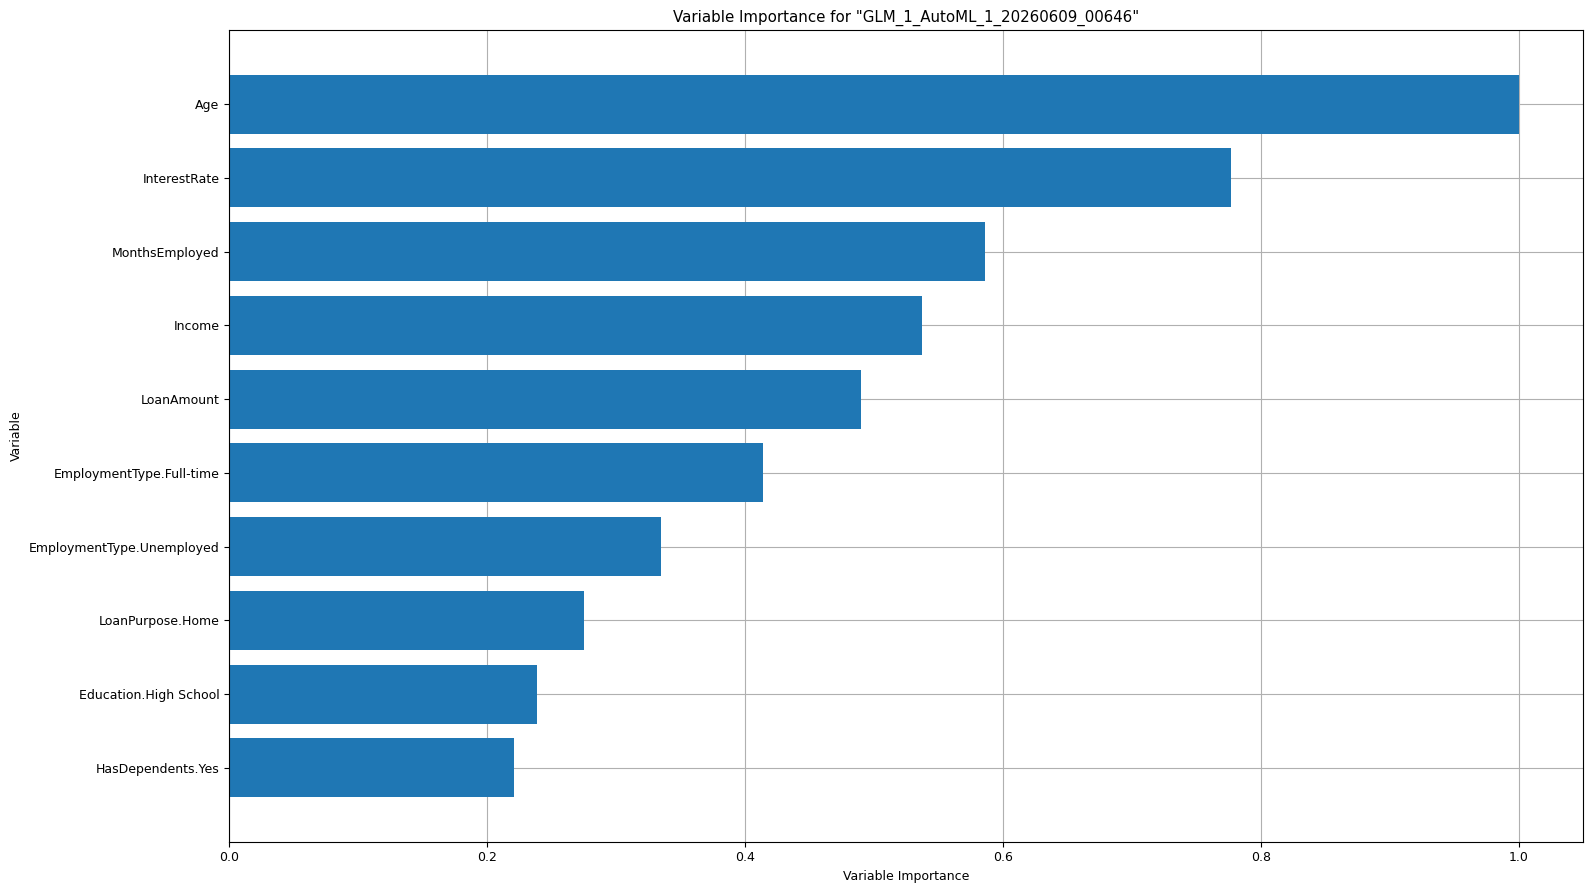

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

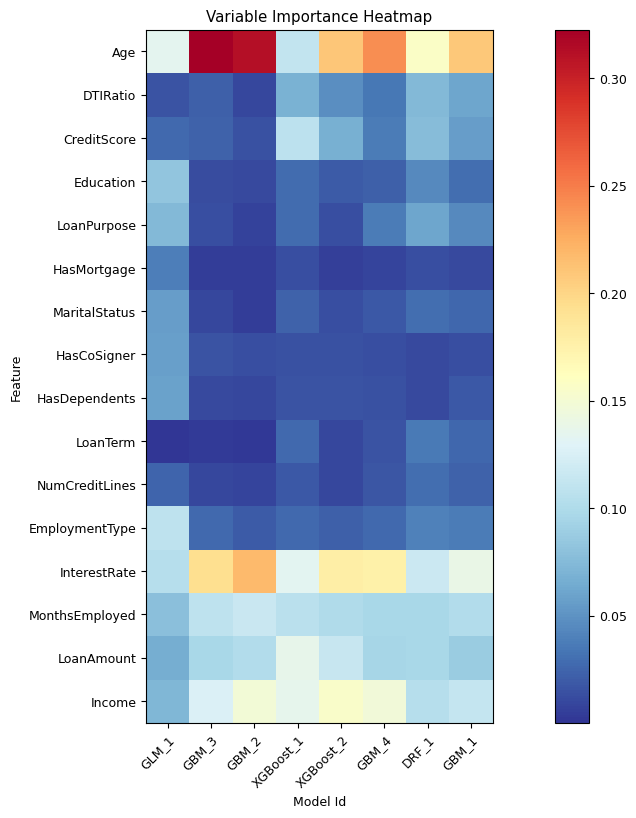

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

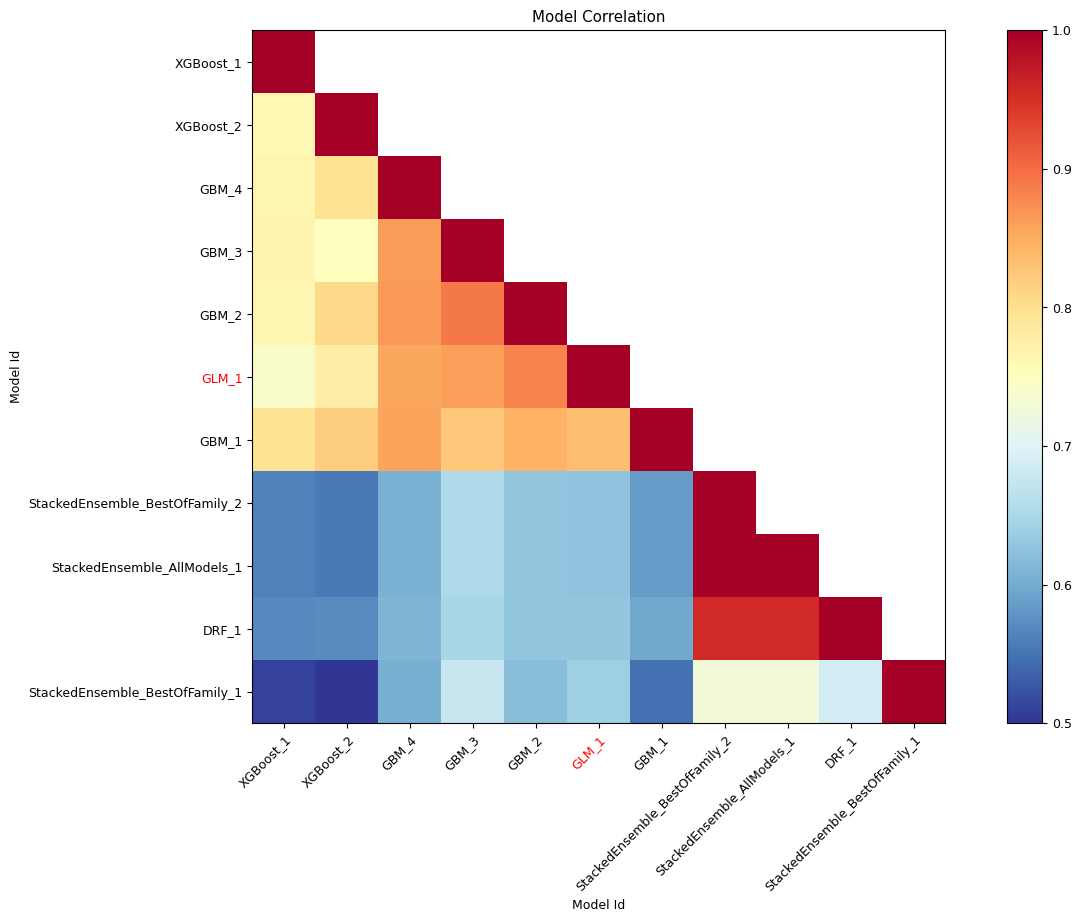

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

h2o.explain could not render all requested explanations.
This can happen for Stacked Ensembles or unsupported model types.
Reason: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_205_sid_9e48 (levels (tmp= py_204_sid_9e48 (as.factor (cols_py py_203_sid_9e48 np.str_('Education'))))))", 'session_id': '_sid_9e48'}



In [12]:
explain_n = min(EXPLAIN_N_ROWS, test_h2o.nrow)
explain_frame = test_h2o[:explain_n, :]

print(f"Generating H2O explainability report on {explain_n} rows...")

try:
    explanations = h2o.explain(
        aml,
        explain_frame,
        render=True,
        include_explanations=[
            "leaderboard",              # Shows the model overview
            "varimp",                   # Global Feature Importance
            "varimp_heatmap",           # Shows feature importance across all models
            "model_correlation_heatmap",# Shows how strongly the models correlate
            "shap_summary",             # Global SHAP beeswarm plot --> inbuild only TreeSHAP! --> only works for GBM, Random Forest (DRF) or XGBoost
            "residual_analysis",        # Shows the distribution of prediction errors
        ],
    )
except Exception as e:
    print("h2o.explain could not render all requested explanations.")
    print("This can happen for Stacked Ensembles or unsupported model types.")
    print("Reason:", e)

# small note so the generated artefacts folder documents this step
with open(os.path.join(EXPLAIN_DIR, "h2o_explain_report_note.txt"), "w") as f:
    f.write(
        "h2o.explain was called on the AutoML object. "
        "Rendered plots appear in the notebook output. "
        "Additional exported artefacts are saved as CSV/PNG in this folder.\n"
    )


# 8.1) Partial dependence plots for top features

Generating PDPs for: ['Age', 'InterestRate', 'MonthsEmployed', 'Income', 'LoanAmount']


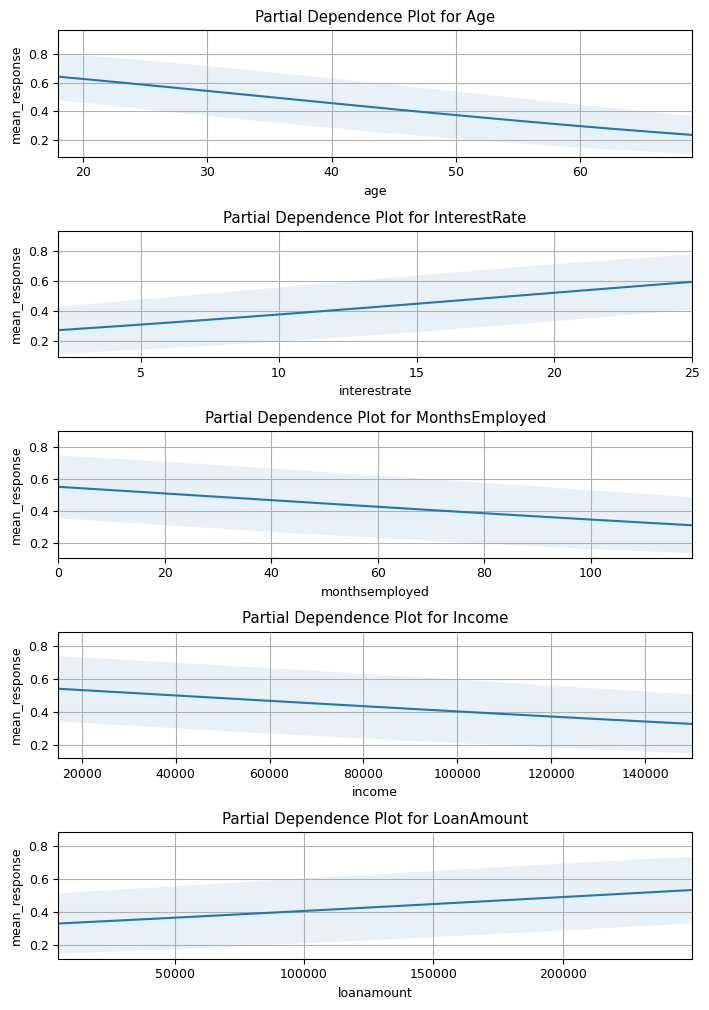

In [13]:
try:

    varimp = leader.varimp()

    if varimp is not None:

        top_features = [row[0] for row in varimp[:5]]

        print("Generating PDPs for:", top_features)

        leader.partial_plot(
            data=test_h2o,
            cols=top_features
        )

    else:
        print(
            "Partial dependence plots were skipped because "
            "the leader model does not provide variable importance."
        )

except Exception as e:

    print("Partial dependence plots could not be generated.")
    print("Reason:", e)

# 8.2) Local row-level explanations

In [14]:

#filter rows
local_rows = [i for i in LOCAL_EXPLAIN_ROW_INDEXES if i < test_h2o.nrow]

# expoert for documentation
pd.DataFrame({"row_index": local_rows}).to_csv(
    os.path.join(EXPLAIN_DIR, "local_explanation_rows.csv"),
    index=False,
)

# one loop
for row_idx in local_rows:
    print("Local explanation for test row:", row_idx)
    try:
        _ = h2o.explain_row(
            aml,
            test_h2o,
            row_index=row_idx,
        )
    except Exception as e:
        print(f"h2o.explain_row failed for row {row_idx}:", e)


Local explanation for test row: 0


# Leaderboard

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_00646,0.756327,0.312441,0.320822,0.333288,0.302096,0.0912622,73513,0.018823,StackedEnsemble,0,0.971959,0.0280411
GLM_1_AutoML_1_20260609_00646,0.753276,0.594712,0.310265,0.326632,0.452762,0.204994,7971,0.001638,GLM,0,0.814584,0.185416
GBM_3_AutoML_1_20260609_00646,0.748815,0.598586,0.313383,0.336037,0.452497,0.204754,3790,0.00511,GBM,0,0.721529,0.278471
GBM_2_AutoML_1_20260609_00646,0.747301,0.606184,0.319083,0.345705,0.456322,0.20823,3688,0.00487,GBM,0,0.624561,0.375439
GBM_1_AutoML_1_20260609_00646,0.746213,0.524453,0.314052,0.336529,0.416638,0.173587,14816,0.0221,GBM,0,0.823574,0.176426
GBM_4_AutoML_1_20260609_00646,0.738162,0.582313,0.302718,0.346047,0.44378,0.196941,3822,0.00499,GBM,0,0.786743,0.213257
XGBoost_2_AutoML_1_20260609_00646,0.730819,0.564621,0.291362,0.339927,0.436636,0.190651,4978,0.00192,XGBoost,0,0.744026,0.255974
XGBoost_1_AutoML_1_20260609_00646,0.710497,0.480719,0.262014,0.361632,0.397192,0.157762,26726,0.006202,XGBoost,0,0.897739,0.102261
DRF_1_AutoML_1_20260609_00646,0.623122,2.00896,0.195344,0.398957,0.355359,0.12628,2500,0.004467,DRF,0,1,0
StackedEnsemble_BestOfFamily_2_AutoML_1_20260609_00646,0.622091,0.350891,0.195109,0.398984,0.31765,0.100901,16490,0.00415,StackedEnsemble,0,0.910012,0.0899885


# SHAP Explanation

...

> Leaderboard shows models with their metrics and their predictions for a given row. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo,predict,p0,p1
StackedEnsemble_BestOfFamily_1_AutoML_1_20260609_00646,0.756327,0.312441,0.320822,0.333288,0.302096,0.0912622,73513,0.018823,StackedEnsemble,0,0.917357,0.0826434
GLM_1_AutoML_1_20260609_00646,0.753276,0.594712,0.310265,0.326632,0.452762,0.204994,7971,0.001638,GLM,1,0.623449,0.376551
GBM_3_AutoML_1_20260609_00646,0.748815,0.598586,0.313383,0.336037,0.452497,0.204754,3790,0.00511,GBM,0,0.58624,0.41376
GBM_2_AutoML_1_20260609_00646,0.747301,0.606184,0.319083,0.345705,0.456322,0.20823,3688,0.00487,GBM,1,0.551382,0.448618
GBM_1_AutoML_1_20260609_00646,0.746213,0.524453,0.314052,0.336529,0.416638,0.173587,14816,0.0221,GBM,1,0.59213,0.40787
GBM_4_AutoML_1_20260609_00646,0.738162,0.582313,0.302718,0.346047,0.44378,0.196941,3822,0.00499,GBM,0,0.63636,0.36364
XGBoost_2_AutoML_1_20260609_00646,0.730819,0.564621,0.291362,0.339927,0.436636,0.190651,4978,0.00192,XGBoost,1,0.655123,0.344877
XGBoost_1_AutoML_1_20260609_00646,0.710497,0.480719,0.262014,0.361632,0.397192,0.157762,26726,0.006202,XGBoost,1,0.75184,0.24816
DRF_1_AutoML_1_20260609_00646,0.623122,2.00896,0.195344,0.398957,0.355359,0.12628,2500,0.004467,DRF,0,1,0
StackedEnsemble_BestOfFamily_2_AutoML_1_20260609_00646,0.622091,0.350891,0.195109,0.398984,0.31765,0.100901,16490,0.00415,StackedEnsemble,0,0.910012,0.0899885


# SHAP Explanation

> SHAP explanation shows contribution of features for a given instance. The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function. H2O implements TreeSHAP which when the features are correlated, can increase contribution of a feature that had no influence on the prediction.

h2o.explain_row failed for row 2: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_276_sid_9e48 (levels (tmp= py_275_sid_9e48 (as.factor (cols_py py_273_sid_9e48 np.str_('Education'))))))", 'session_id': '_sid_9e48'}



# 9) SHAP

In [15]:
# explain final calibrated PD-Pipeline

X_background = test_final[FEATURES].sample(
    n=min(20, len(test_final)),
    random_state=42
)

X_shap = test_final[FEATURES].sample(
    n=min(30, len(test_final)),
    random_state=42
)


def predict_final_pd_fn_h2o(data):

    df = pd.DataFrame(
        data,
        columns=FEATURES
    )

    tmp = df.copy()
    tmp[TARGET] = 0

    h2o_frame = make_h2o_frame(tmp, TARGET)

    pd_raw = get_positive_class_proba_h2o(
        leader,
        h2o_frame
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    pd_final = apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

    return pd_final


explainer = shap.KernelExplainer(
    predict_final_pd_fn_h2o,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)


  0%|          | 0/30 [00:00<?, ?it/s]

## 9.1) SHAP Summery Plot

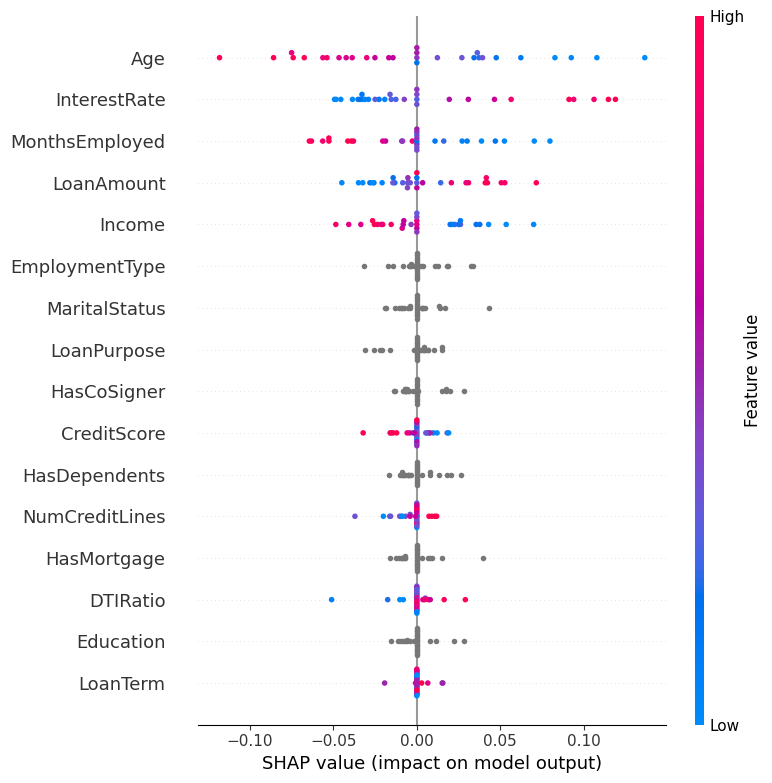

In [16]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## 9.2) SHAP Bar Plot

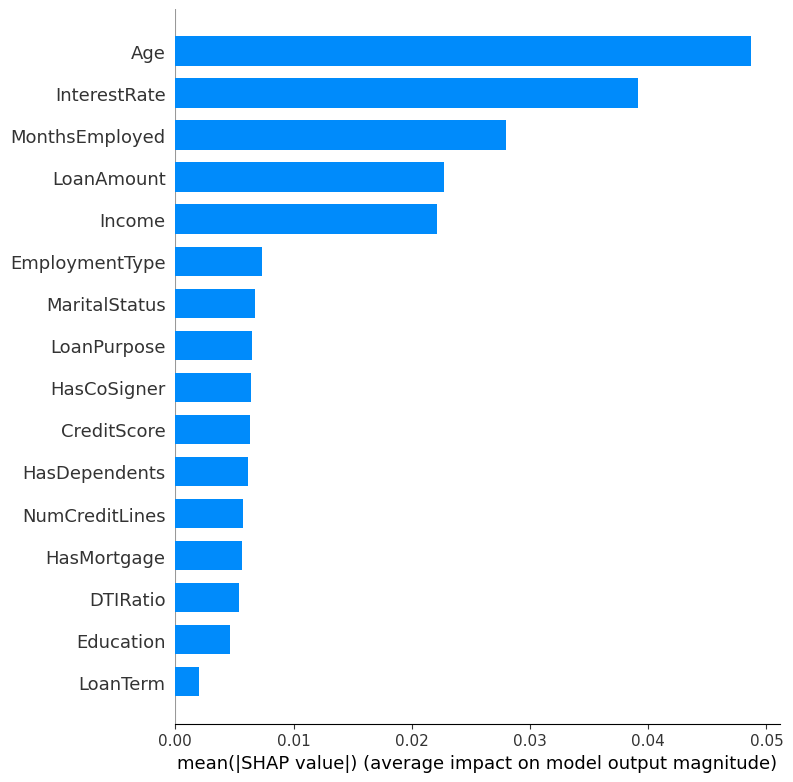

In [17]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# 10) LIME

In [18]:
# prepare data

X_train = train_final[FEATURES].copy()
y_train = train_final[TARGET].astype(int)

X_test = test_final[FEATURES].copy()
y_test = test_final[TARGET].astype(int)

In [19]:
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["Non-Default", "Default"],
    mode="classification"
)


def predict_final_pd_from_encoded_h2o(data):

    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:
            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )
        else:
            df_original[col] = df_encoded[col]

    df_original = df_original[X_train.columns]

    tmp = df_original.copy()
    tmp[TARGET] = 0

    h2o_frame = make_h2o_frame(tmp, TARGET)

    pd_raw = get_positive_class_proba_h2o(
        leader,
        h2o_frame
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    return apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
        pd_floor=PD_FLOOR
    )


def predict_proba_fn_lime_h2o(data):

    pd_final = predict_final_pd_from_encoded_h2o(data)

    return np.column_stack([
        1 - pd_final,
        pd_final
    ])


instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime_h2o,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 10.1) Save LIME

In [20]:
lime_exp.save_to_file(
    os.path.join(OUT_DIR, "lime_explanation.html")
)

print("Level 3 explainability outputs saved.")

Level 3 explainability outputs saved.


# 11) Save Outputs

In [ ]:

moc_summary = pd.DataFrame({
    "component": [
        "MoC_A_mean_train",
        "MoC_C_mean_train",
        "Total_MoC_mean_train",
        "MoC_A_mean_test",
        "MoC_C_mean_test",
        "Total_MoC_mean_test",
    ],
    "value": [
        float(np.mean(moc_a_train)),
        float(np.mean(moc_c_train)),
        float(np.mean(moc_a_train + moc_c_train)),
        float(np.mean(moc_a_test)),
        float(np.mean(moc_c_test)),
        float(np.mean(moc_a_test + moc_c_test)),
    ],
    "note": [
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
    ],
})

validation_summary = pd.DataFrame(
    [
        {"metric": k, "value": v}
        for d in [
            raw_train_metrics,
            raw_test_metrics,
            be_train_metrics,
            be_test_metrics,
            final_train_metrics,
            final_test_metrics,
        ]
        for k, v in d.items()
    ]
)

intercept_df = pd.DataFrame({
    "intercept_type": ["calibration_alpha_shift"],
    "value": [alpha_shift],
})
explainability_summary = pd.DataFrame({
    "method": [
        "h2o.explain",
        "h2o.explain_row",
        "predict_contributions",
        "SHAP-style bar plot",
        "Local SHAP-style plot",
        "Partial Dependence Plot",
        "Individual Conditional Expectation Plot",
    ],
    "level": [
        "global",
        "local",
        "local/additive",
        "global",
        "local",
        "global",
        "local/feature effect",
    ],
    "source": [
        "H2O built-in",
        "H2O built-in",
        "H2O built-in",
        "derived from H2O contributions",
        "derived from H2O contributions",
        "H2O built-in",
        "H2O built-in",
    ],
    "note": [
        "Automatic explainability report",
        "Explanation for one observation",
        "TreeSHAP-style contributions if supported by model",
        "Mean absolute contribution aggregation",
        "Contribution plot for one observation",
        "Average marginal feature effect",
        "Observation-level feature effect curves",
    ],
})


# ------------------------------------------------------------
# Method summary and limitations
# ------------------------------------------------------------

method_summary = pd.DataFrame({
    "aspect": [
        "Modelling framework",
        "Input representation",
        "Calibration",
        "MoC_A",
        "MoC_C",
        "Risk grades",
        "PD floor",
        "H2O built-in explainability",
        "PDP",
        "SHAP-style contributions",
        "Regulatory status",
    ],
    "description": [
        "H2O AutoML on raw features",
        "Raw numerical and categorical features, without WoE preprocessing",
        "Global logit shift to proxy LRADR",
        "Method sensitivity proxy based on calibration uplift",
        "Bootstrap-based estimation uncertainty proxy",
        "Quantile-based monotonic risk-grade mapping",
        f"Applied: {APPLY_PD_FLOOR}, floor={PD_FLOOR}",
        "h2o.explain and h2o.explain_row",
        "H2O partial_plot",
        "H2O predict_contributions where supported",
        "Academic IRB-near approximation, not a production IRB model",
    ],
})

limitations_text = """
This workflow implements an H2O AutoML-based PD modelling pipeline on raw features.
It is designed as an AutoML alternative to a classical WoE/logistic-regression scorecard.

What is feasible here:
- raw-feature H2O AutoML modelling without WoE preprocessing
- discrimination metrics such as AUC, Gini, and KS
- grouped calibration checks
- best-estimate calibration scaffold via global logit shift
- MoC_A and MoC_C proxy calculations
- monotonic post-processing through ordered risk-grade mapping
- scorecard-like risk-grade table with PD ranges, observed default rates, and calibration gaps
- H2O built-in explainability via h2o.explain and h2o.explain_row
- Partial Dependence Plots and Individual Conditional Expectation Plots
- SHAP-style feature contribution outputs where the selected H2O model supports predict_contributions

What is not equivalent to the classical scorecard:
- no WoE bins are used before model training
- no logistic-regression coefficients are generally available for AutoML ensemble leaders
- no bin-level logit contributions are available
- coefficient sign review is not generally applicable
- monotonicity is introduced after model estimation, not at feature-transformation level

What remains impossible or only partially defensible with this dataset:
- out-of-time backtesting, because no observation dates are available
- vintage analysis, because no dates are available
- long-run average default rate from historical cycles, because this is a single snapshot
- segment-specific models or calibration, because no formal portfolio segmentation fields are available
- MoC_B based on policy, process, or business changes over time
- MoC_A and MoC_C are implemented as methodological proxies rather than regulatory capital-model MoCs
- regulatory default definition according to Article 178 CRR cannot be verified from this dataset
- only proxy LRADR due to missing time dimension and missing long-term historical default observations
""".strip()

model_package = {
    "target": TARGET,
    "output_dir": OUT_DIR,
    "h2o_model_dir": MODEL_DIR,
    "h2o_saved_model_path": saved_model_path,
    "time_limit": MAX_RUNTIME_SECS,
    "observed_train_dr": observed_train_dr,
    "proxy_lradr": proxy_lradr,
    "conservatism_uplift": CONSERVATISM_UPLIFT,
    "lradr_type": "proxy",
    "pd_floor": PD_FLOOR,
    "n_risk_grades_requested": N_RISK_GRADES,
    "n_risk_grades_final": int(scorecard_df["final_risk_grade"].nunique()),
    "seed": SEED,
    "n_features_final": int(train_final.shape[1]),
    "features_final": list(train_final.columns),
    "explainability_output_dir": EXPLAIN_DIR,
}


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

leaderboard.to_csv(os.path.join(OUT_DIR, "model_selection_table.csv"), index=False)
intercept_df.to_csv(os.path.join(OUT_DIR, "intercepts.csv"), index=False)

initial_grade_table.to_csv(os.path.join(OUT_DIR, "initial_risk_grade_table.csv"), index=False)
scorecard_df.to_csv(os.path.join(OUT_DIR, "scorecard_table.csv"), index=False)

pd_results_test = pd.DataFrame({
    "y_true": y_test_final,
    "pd_raw": pd_test_raw,
    "pd_be": pd_test_be,
    "moc_a": moc_a_test,
    "moc_c": moc_c_test,
    "pd_final": pd_test_final,
})

pd_results_test.to_csv(os.path.join(OUT_DIR, "pd_results_test.csv"), index=False)
rank_ordering.to_csv(os.path.join(OUT_DIR, "rank_ordering.csv"), index=False)

cal_table_raw.to_csv(os.path.join(OUT_DIR, "calibration_table_raw.csv"), index=False)
cal_table_be.to_csv(os.path.join(OUT_DIR, "calibration_table_be.csv"), index=False)
cal_table_final.to_csv(os.path.join(OUT_DIR, "calibration_table_final.csv"), index=False)

stability_summary.to_csv(os.path.join(OUT_DIR, "stability_summary.csv"), index=False)
validation_summary.to_csv(os.path.join(OUT_DIR, "validation_summary.csv"), index=False)
moc_summary.to_csv(os.path.join(OUT_DIR, "moc_summary.csv"), index=False)
method_summary.to_csv(os.path.join(OUT_DIR, "method_summary.csv"), index=False)
explainability_summary.to_csv(os.path.join(EXPLAIN_DIR, "h2o_explainability_summary.csv"), index=False)

with open(os.path.join(OUT_DIR, "limitations.txt"), "w", encoding="utf-8") as f:
    f.write(limitations_text)

with open(os.path.join(OUT_DIR, "model_package.json"), "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2, default=str)


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Saved outputs to:", OUT_DIR)
print("Saved explainability outputs to:", EXPLAIN_DIR)
print("Train final shape:", train_final.shape)
print("Test final shape:", test_final.shape)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print()
print(validation_summary.head(12))
print()
print(moc_summary)
print()
print("Final monotonic scorecard/rating table:")
print(scorecard_df)



Saved outputs to: /content/h2o_level3_outputs
Saved explainability outputs to: /content/h2o_level3_outputs/explainability
Train final shape: (204277, 18)
Test final shape: (51070, 18)
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6886564142805582

               metric          value
0       train_raw_auc       0.746691
1      train_raw_gini       0.493383
2        train_raw_ks       0.362847
3     train_raw_brier       0.204775
4   train_raw_logloss       0.594059
5   train_raw_hl_like  106982.348871
6   train_raw_mean_pd       0.429628
7    train_raw_obs_dr       0.116127
8        test_raw_auc       0.753271
9       test_raw_gini       0.506542
10        test_raw_ks       0.377906
11     test_raw_brier       0.204994

              component     value  \
0      MoC_A_mean_train  0.007548   
1      MoC_C_mean_train  0.055715   
2  Total_MoC_mean_train  0.063263   
3       MoC_A_mean_test  0.007605   
4       MoC_C_mean_test  0.074533   
5   Total_MoC_mean_test  0.082139   

       

#  12) Evaluation: Lorenz Curve & Calibration Curve

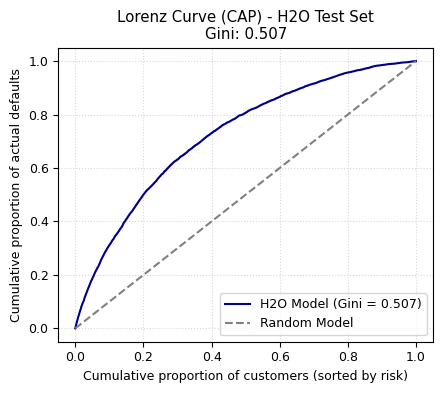

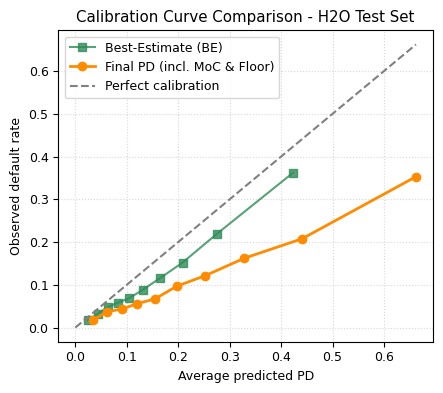

Saved H2O IRBA-compliant plots to: /content/h2o_level3_outputs/thesis_plots


In [22]:
# H2O data preparation for Scikit-Learn & Matplotlib
# (Converts H2O frames to Pandas/NumPy if they are still in H2O format)
try:
    y_test_true = y_test_final.as_data_frame().iloc[:, 0].values if hasattr(y_test_final, "as_data_frame") else np.asarray(y_test_final)
    pd_test_be_arr = pd_test_be.as_data_frame().iloc[:, 0].values if hasattr(pd_test_be, "as_data_frame") else np.asarray(pd_test_be)
    pd_test_final_arr = pd_test_final.as_data_frame().iloc[:, 0].values if hasattr(pd_test_final, "as_data_frame") else np.asarray(pd_test_final)
except Exception:
    # Fallback,if it is NumPy/Pandas-Objekte already
    y_test_true = np.asarray(y_test_final)
    pd_test_be_arr = np.asarray(pd_test_be)
    pd_test_final_arr = np.asarray(pd_test_final)


# IRB Best Practice: Use Unbiased Best-Estimate PDs for Lorenz/Gini
# to prevent artificial Gini deflation caused by regulatory floors.
y_test_proba_lorenz = pd_test_be_arr

plt.rcParams.update({
    "font.size": 9
})

# ============================================================
#  Lorenz curve (CAP / Cumulative Gains) - H2O Test Set
# ============================================================

# Evaluate the discriminatory power of the H2O PD model.
# Customers are sorted from highest predicted risk to lowest.
#
# Interpretation:
# - A curve far above the diagonal indicates strong risk separation.
# - The diagonal represents a random model.
# - The Gini coefficient summarizes discrimination (> 0.50 is strong).

# Create DataFrame and sort observations by predicted PD
# Create DataFrame and sort observations by unbiased predicted PD
df_lorenz = pd.DataFrame({"y_true": y_test_true, "y_proba": y_test_proba_lorenz})
df_lorenz = df_lorenz.sort_values(by="y_proba", ascending=False).reset_index(drop=True)

# Cumulative percentage of customers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Cumulative percentage of observed defaults
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# Convert ROC-AUC into Gini coefficient based on BE-PD
roc_auc = roc_auc_score(y_test_true, y_test_proba_lorenz)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
plt.plot(cum_population, cum_defaults, color="darkblue", label=f"H2O Model (Gini = {gini_score:.3f})")
# Random model benchmark
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("Cumulative proportion of customers (sorted by risk)")
plt.ylabel("Cumulative proportion of actual defaults")
plt.title(f"Lorenz Curve (CAP) - H2O Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_h2o_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()



# ============================================================
# 2. Combined Calibration Curve - H2O Test Set
# ============================================================
# Purpose:
# Compare the calibrated Best-Estimate (BE) PDs against the
# final conservative PDs (including MoCs and regulatory floors).
#
# Interpretation:
# - The BE line reflects the unbiased model fit after the alpha-shift.
# - The Final PD line incorporates mandated regulatory margins.
# - Points below the diagonal indicate compliant, conservative risk overestimation.

# 1. Calculation for unbiased Best-Estimate (BE) PDs
prob_true_be, prob_pred_be = calibration_curve(
    y_test_true,
    pd_test_be_arr,
    n_bins=10,
    strategy="quantile"
)

# 2. Calculation for final regulatory PDs
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_test_final_arr,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Best-Estimate (BE) line (green)
plt.plot(prob_pred_be, prob_true_be, "s-", color="seagreen", alpha=0.8, label="Best-Estimate (BE)")

# final PD line  (orange)
plt.plot(prob_pred_final, prob_true_final, "o-", color="darkorange", lw=2, label="Final PD (incl. MoC & Floor)")

# Draw a perfect calibration line (up to the maximum predicted PD)
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - H2O Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_h2o_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved H2O IRBA-compliant plots to:", PLOT_DIR)

## 12.1) Output of Scores

In [23]:
# convert in numpy/pandas
try:
    y_test_true_arr = y_test_final.as_data_frame().iloc[:, 0].values if hasattr(y_test_final, "as_data_frame") else np.asarray(y_test_final)
    pd_test_be_arr = pd_test_be.as_data_frame().iloc[:, 0].values if hasattr(pd_test_be, "as_data_frame") else np.asarray(pd_test_be)
    pd_test_final_arr = pd_test_final.as_data_frame().iloc[:, 0].values if hasattr(pd_test_final, "as_data_frame") else np.asarray(pd_test_final)
except Exception:
    # Fallback
    y_test_true_arr = np.asarray(y_test_final)
    pd_test_be_arr = np.asarray(pd_test_be)
    pd_test_final_arr = np.asarray(pd_test_final)

# calculate Gini-coefficient using the prepared H2O arrays
auc_be = roc_auc_score(y_test_true_arr, pd_test_be_arr)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_true_arr, pd_test_final_arr)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy
brier_be = brier_score_loss(y_test_true_arr, pd_test_be_arr)
brier_final = brier_score_loss(y_test_true_arr, pd_test_final_arr)

# evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# Save as CSV for the H2O model evaluation
irba_metrics_summary.to_csv(os.path.join(OUT_DIR, "irba_performance_metrics_h2o.csv"), index=False)

print("H2O CORE IRBA PERFORMANCE METRICS (TEST SET)")
print(irba_metrics_summary.to_string(index=False))


H2O CORE IRBA PERFORMANCE METRICS (TEST SET)
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.506542                 0.093463
Final (incl. MoC & Floor)          0.499585                 0.114623
